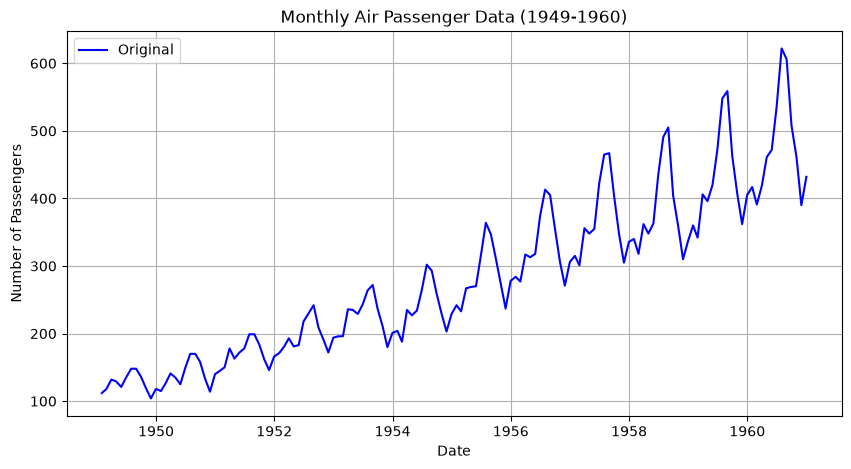

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Load a built-in time-series dataset (Monthly Airline Passengers)
data = sm.datasets.get_rdataset("AirPassengers", "datasets").data

# The dataset has 'time' (decimal years) and 'value'. Let's give it a proper datetime index.
data['Month'] = pd.date_range(start='1949-01', periods=len(data), freq='ME')
data.set_index('Month', inplace=True)
data.drop(columns=['time'], inplace=True)
data.columns = ['Passengers']

# 2. Plot the raw time-series data
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['Passengers'], label='Original', color='blue')
plt.title('Monthly Air Passenger Data (1949-1960)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.legend()
plt.show()


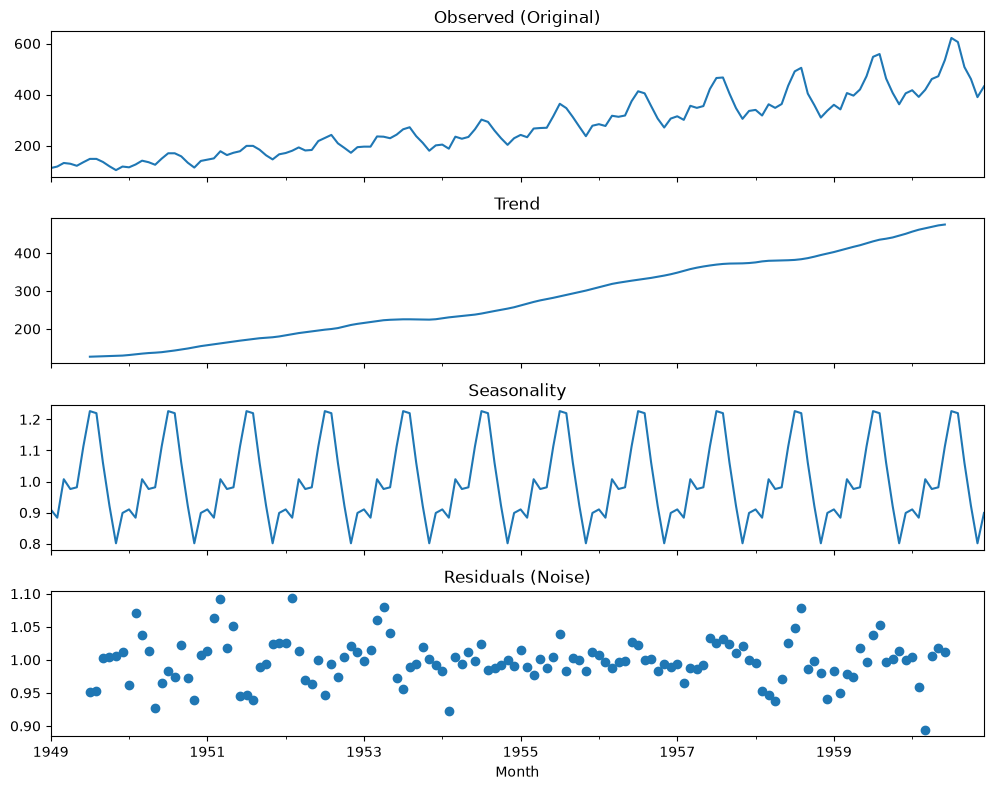

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose using a multiplicative model
result = seasonal_decompose(data['Passengers'], model='multiplicative')

# Plot the decomposed components
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Original)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonality')
result.resid.plot(ax=axes[3], title='Residuals (Noise)', style='o')

plt.tight_layout()
plt.show()

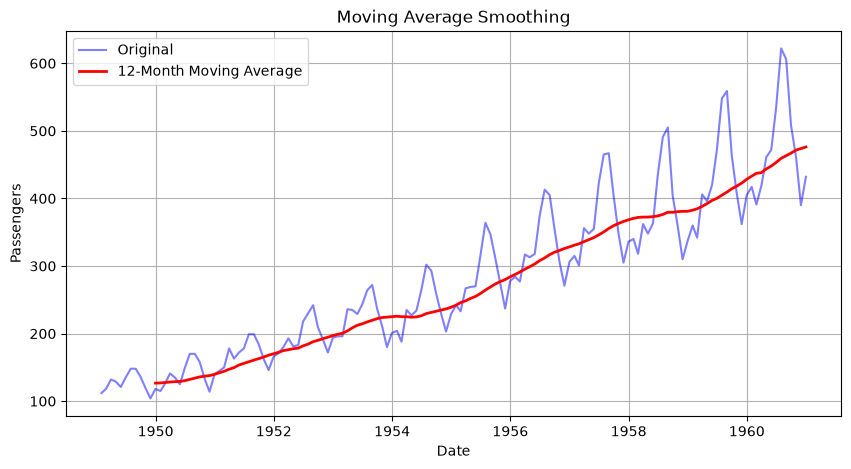

In [3]:
# Calculate a 12-month moving average
data['12_Month_MA'] = data['Passengers'].rolling(window=12).mean()

# Plot original data vs Moving Average
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['Passengers'], label='Original', alpha=0.5, color='blue')
plt.plot(data.index, data['12_Month_MA'], label='12-Month Moving Average', color='red', linewidth=2)

plt.title('Moving Average Smoothing')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()
